# 3D Scene Graph -> JaxFEM

**Konzept:** Bauteile als Knoten, raeumliche Beziehungen als Kanten -- der Szenegraph
steuert automatisch Randbedingungen, Lastpfade und Netzaufbau fuer JaxFEM.

```
Semantische Geometrie (Bauteile: Wand, Stuetze, Decke)
   +-- DBSCAN-Clustering -> Objekt-Instanzen
       +-- Feature-Extraktion (Volumen, BBox, Schwerpunkt)
           +-- Raeumliche Beziehungsanalyse (adjacent, above, contains)
               +-- NetworkX DiGraph (Scene Graph)
                   +-- Graphanalyse (Topologie -> Randbedingungen)
                   +-- GMSH Tet4-Netz -> JaxFEM Solver
                       +-- Ergebnis-Visualisierung (PyVista)
```

**Einheiten:** kN, m  
**Bezug:** Poux & Lehtola (2025) -- *3D Scene Graphs for Spatial AI + LLMs*

In [23]:
import numpy as onp
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import json
import pathlib
from typing import Dict, List, Tuple, Optional
from scipy.spatial import cKDTree, ConvexHull
from collections import deque

# Optional notebook dependencies -------------------------------------------------
# The project venv used by this notebook may not contain networkx/scikit-learn.
# To keep the notebook executable, provide compact fallbacks for the small subset
# of APIs used below.
try:
    import networkx as nx
except ModuleNotFoundError:
    class _NodeView:
        def __init__(self, graph): self._graph = graph
        def __iter__(self): return iter(self._graph._nodes)
        def __len__(self): return len(self._graph._nodes)
        def __getitem__(self, node): return self._graph._nodes[node]
        def __call__(self, data=False):
            return list(self._graph._nodes.items()) if data else list(self._graph._nodes.keys())

    class _EdgeView:
        def __init__(self, graph): self._graph = graph
        def __iter__(self): return iter(self._graph._edges)
        def __len__(self): return len(self._graph._edges)
        def __getitem__(self, edge): return self._graph._edges[edge]
        def __call__(self, data=False):
            if data:
                return [(u, v, d) for (u, v), d in self._graph._edges.items()]
            return list(self._graph._edges.keys())

    class _DiGraph:
        def __init__(self):
            self._nodes = {}
            self._edges = {}
            self.nodes = _NodeView(self)
            self.edges = _EdgeView(self)
        def add_node(self, node, **attrs):
            self._nodes.setdefault(node, {}).update(attrs)
        def add_edge(self, u, v, **attrs):
            self._nodes.setdefault(u, {})
            self._nodes.setdefault(v, {})
            self._edges[(u, v)] = dict(attrs)
        def number_of_nodes(self): return len(self._nodes)
        def number_of_edges(self): return len(self._edges)
        def in_edges(self, node): return [(u, v) for (u, v) in self._edges if v == node]
        def out_edges(self, node): return [(u, v) for (u, v) in self._edges if u == node]
        def degree(self):
            return [(n, sum(1 for e in self._edges if n in e)) for n in self._nodes]

    def _weak_components(graph):
        seen = set()
        comps = 0
        adjacency = {n: set() for n in graph._nodes}
        for u, v in graph._edges:
            adjacency[u].add(v)
            adjacency[v].add(u)
        for start in graph._nodes:
            if start in seen:
                continue
            comps += 1
            stack = [start]
            seen.add(start)
            while stack:
                n = stack.pop()
                for nb in adjacency[n]:
                    if nb not in seen:
                        seen.add(nb)
                        stack.append(nb)
        return comps

    def _spring_layout(graph, seed=None):
        nodes = list(graph._nodes)
        if not nodes:
            return {}
        angles = onp.linspace(0, 2 * onp.pi, len(nodes), endpoint=False)
        return {n: (float(onp.cos(a)), float(onp.sin(a))) for n, a in zip(nodes, angles)}

    def _draw_networkx(graph, pos, ax=None, node_color=None, edge_color=None,
                       node_size=800, font_size=8, arrows=True, arrowsize=20,
                       width=2, **kwargs):
        ax = ax or plt.gca()
        nodes = list(graph.nodes)
        node_color = node_color or ['#aaaaaa'] * len(nodes)
        xy = onp.array([pos[n] for n in nodes], dtype=float)
        ax.scatter(xy[:, 0], xy[:, 1], s=node_size, c=node_color, zorder=3,
                   edgecolors='black', linewidths=0.5)
        for n, (x, y) in zip(nodes, xy):
            ax.text(x, y, str(n), ha='center', va='center', fontsize=font_size, zorder=4)
        edges = list(graph.edges)
        edge_color = edge_color or ['#888888'] * len(edges)
        for (u, v), col in zip(edges, edge_color):
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            if arrows:
                ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                            arrowprops=dict(arrowstyle='-|>', color=col, lw=width,
                                            mutation_scale=arrowsize), zorder=2)
            else:
                ax.plot([x1, x2], [y1, y2], color=col, lw=width, zorder=2)

    def _draw_networkx_edge_labels(graph, pos, edge_labels, font_size=7, ax=None, **kwargs):
        ax = ax or plt.gca()
        for (u, v), label in edge_labels.items():
            x = 0.5 * (pos[u][0] + pos[v][0])
            y = 0.5 * (pos[u][1] + pos[v][1])
            ax.text(x, y, str(label), fontsize=font_size, ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    class _NXFallback:
        __version__ = 'fallback (minimal)'
        DiGraph = _DiGraph
        number_weakly_connected_components = staticmethod(_weak_components)
        spring_layout = staticmethod(_spring_layout)
        draw_networkx = staticmethod(_draw_networkx)
        draw_networkx_edge_labels = staticmethod(_draw_networkx_edge_labels)

    nx = _NXFallback()
    print('Hinweis: networkx nicht installiert; nutze minimalen Notebook-Fallback.')

try:
    from sklearn.cluster import DBSCAN
except ModuleNotFoundError:
    class DBSCAN:
        """Small DBSCAN fallback compatible with the notebook's `.fit(...).labels_` use."""
        def __init__(self, eps=0.5, min_samples=5):
            self.eps = eps
            self.min_samples = min_samples
            self.labels_ = None
        def fit(self, X):
            X = onp.asarray(X, dtype=float)
            n = len(X)
            labels = onp.full(n, -1, dtype=int)
            if n == 0:
                self.labels_ = labels
                return self
            neighbors = cKDTree(X).query_ball_point(X, self.eps)
            visited = onp.zeros(n, dtype=bool)
            cluster_id = 0
            for i in range(n):
                if visited[i]:
                    continue
                visited[i] = True
                if len(neighbors[i]) < self.min_samples:
                    continue
                labels[i] = cluster_id
                queue = deque(neighbors[i])
                queued = set(neighbors[i])
                while queue:
                    p = queue.popleft()
                    if not visited[p]:
                        visited[p] = True
                        if len(neighbors[p]) >= self.min_samples:
                            for q in neighbors[p]:
                                if q not in queued:
                                    queue.append(q)
                                    queued.add(q)
                    if labels[p] == -1:
                        labels[p] = cluster_id
                cluster_id += 1
            self.labels_ = labels
            return self
    print('Hinweis: scikit-learn nicht installiert; nutze DBSCAN-Fallback.')

import gmsh
import meshio
import pyvista as pv

from jax_fem.generate_mesh import Mesh
from jax_fem.problem import Problem
from jax_fem.solver import solver
from jax_fem.utils import save_sol

DATA_DIR = pathlib.Path('../data')
DATA_DIR.mkdir(exist_ok=True)
(DATA_DIR / 'vtk').mkdir(exist_ok=True)
(DATA_DIR / 'msh').mkdir(exist_ok=True)

pv.OFF_SCREEN = True

print('JAX     :', jax.__version__)
print('gmsh    :', gmsh.__version__)
print('meshio  :', meshio.__version__)
print('pyvista :', pv.__version__)
print('networkx:', nx.__version__)


Hinweis: networkx nicht installiert; nutze minimalen Notebook-Fallback.
Hinweis: scikit-learn nicht installiert; nutze DBSCAN-Fallback.
JAX     : 0.6.2
gmsh    : 4.15.2
meshio  : 5.3.5
pyvista : 0.47.3
networkx: fallback (minimal)


## 0 -- Konfiguration

In [24]:
# Netz
MESH_SIZE = 0.25    # m -- Tet4-Elementgroesse

# Material (Beton C25/30)
E_DEFAULT    = 30_000.0   # kN/m2
NU_DEFAULT   = 0.2
GAMMA_BETON  = 25.0       # kN/m3

# Lasten
Q_NUTZLAST   = 5.0        # kN/m2

# Scene-Graph-Parameter
DBSCAN_EPS         = 0.6   # m
DBSCAN_MIN_SAMPLES = 5
REL_THRESHOLD      = 3.0   # m
ADJ_TOLERANCE      = 0.05  # m

print(f'Elementgroesse : {MESH_SIZE} m')
print(f'Nutzlast       : {Q_NUTZLAST} kN/m2')
print(f'DBSCAN eps     : {DBSCAN_EPS} m')

Elementgroesse : 0.25 m
Nutzlast       : 5.0 kN/m2
DBSCAN eps     : 0.6 m


## Schritt 1 -- Semantische Punktwolke erzeugen

Synthetische semantische Punktwolke eines Tragwerks:
zwei Waende, eine Stuetze, eine Deckenplatte.
Jeder Punkt traegt ein semantisches Label (`wall`, `column`, `slab`).

Entspricht dem Tutorial-Konzept (Poux & Lehtola 2025, Step 1):
*semantische Punktwolke als Eingabe fuer den Scene-Graph-Pipeline.*

In [25]:
rng = onp.random.default_rng(42)

def sample_box(x0, y0, z0, dx, dy, dz, n_pts, label):
    pts = onp.column_stack([
        rng.uniform(x0, x0 + dx, n_pts),
        rng.uniform(y0, y0 + dy, n_pts),
        rng.uniform(z0, z0 + dz, n_pts),
    ])
    return pts, [label] * n_pts

# Tragwerk: 4x4 m Grundriss, 2.8 m Geschosshoehe + 0.2 m Decke
# (x0, y0, z0, dx, dy, dz, n, label, E, nu)
BAUTEILE_DEF = [
    (0.0, 0.0, 0.0, 4.0, 0.2, 2.8, 2000, 'wall',   30_000.0, 0.2),
    (0.0, 3.8, 0.0, 4.0, 0.2, 2.8, 2000, 'wall',   30_000.0, 0.2),
    (1.9, 1.9, 0.0, 0.2, 0.2, 2.8,  300, 'column', 35_000.0, 0.2),
    (0.0, 0.0, 2.8, 4.0, 4.0, 0.2, 3000, 'slab',   30_000.0, 0.2),
]

all_pts, all_labels, bauteil_meta = [], [], []
for x0, y0, z0, dx, dy, dz, n, label, E, nu in BAUTEILE_DEF:
    pts, lbs = sample_box(x0, y0, z0, dx, dy, dz, n, label)
    all_pts.append(pts)
    all_labels.extend(lbs)
    bauteil_meta.append({
        'label'   : label,
        'E'       : E,
        'nu'      : nu,
        'bbox_min': onp.array([x0, y0, z0]),
        'bbox_max': onp.array([x0+dx, y0+dy, z0+dz]),
        'dims'    : onp.array([dx, dy, dz]),
        'origin'  : onp.array([x0, y0, z0]),
    })

cloud_pts    = onp.vstack(all_pts)
cloud_labels = onp.array(all_labels)

unique_labels, counts = onp.unique(cloud_labels, return_counts=True)
print(f'Semantische Punktwolke: {len(cloud_pts)} Punkte')
for lbl, cnt in zip(unique_labels, counts):
    print(f'  {lbl:8s}: {cnt} Punkte')

Semantische Punktwolke: 7300 Punkte
  column  : 300 Punkte
  slab    : 3000 Punkte
  wall    : 4000 Punkte


## Schritt 2 -- Visualisierung der semantischen Punktwolke

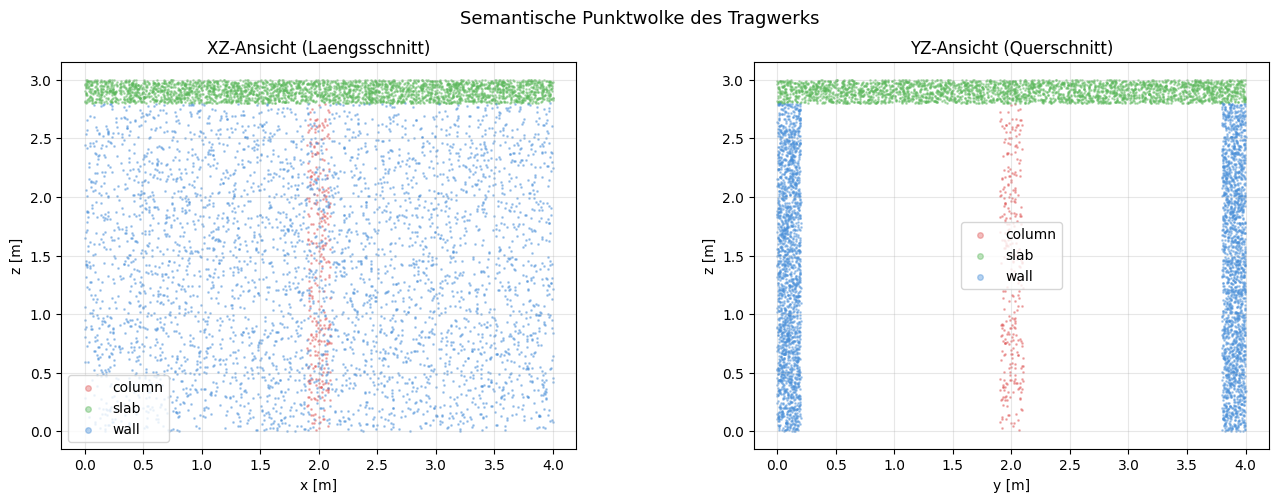

In [26]:
COLOR_MAP = {'wall': '#4a90d9', 'column': '#e05c5c', 'slab': '#5cb85c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lbl in onp.unique(cloud_labels):
    mask = (cloud_labels == lbl)
    pts  = cloud_pts[mask]
    axes[0].scatter(pts[:, 0], pts[:, 2], s=1, c=COLOR_MAP.get(lbl, 'gray'),
                    alpha=0.4, label=lbl)
    axes[1].scatter(pts[:, 1], pts[:, 2], s=1, c=COLOR_MAP.get(lbl, 'gray'),
                    alpha=0.4, label=lbl)

for ax, xlabel, title in [(axes[0], 'x [m]', 'XZ-Ansicht (Laengsschnitt)'),
                           (axes[1], 'y [m]', 'YZ-Ansicht (Querschnitt)')]:
    ax.set_xlabel(xlabel); ax.set_ylabel('z [m]')
    ax.set_title(title); ax.set_aspect('equal')
    ax.legend(markerscale=4); ax.grid(True, alpha=0.3)

plt.suptitle('Semantische Punktwolke des Tragwerks', fontsize=13)
plt.tight_layout()
plt.show()

## Schritt 3 -- Objekt-Instanziierung (DBSCAN-Clustering)

Poux & Lehtola (2025), Step 4: Fuer jedes semantische Label wird DBSCAN angewendet,
um diskrete Objekt-Instanzen zu finden (z.B. wall_0 = Wand_A, wall_1 = Wand_B).

In [27]:
def extract_semantic_objects(
    pts: onp.ndarray,
    labels: onp.ndarray,
    eps: float = DBSCAN_EPS,
    min_samples: int = DBSCAN_MIN_SAMPLES,
) -> Dict:
    objects = {}
    for label in onp.unique(labels):
        mask  = (labels == label)
        l_pts = pts[mask]
        if len(l_pts) < min_samples:
            continue
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(l_pts)
        for cluster_id in onp.unique(clustering.labels_):
            if cluster_id == -1:
                continue
            c_mask  = (clustering.labels_ == cluster_id)
            c_pts   = l_pts[c_mask]
            obj_key = f'{label}_{cluster_id}'
            objects[obj_key] = {
                'points'        : c_pts,
                'centroid'      : c_pts.mean(axis=0),
                'bounds_min'    : c_pts.min(axis=0),
                'bounds_max'    : c_pts.max(axis=0),
                'semantic_label': str(label),
                'point_count'   : len(c_pts),
            }
    return objects


def snap_objects_to_exact_boxes(objects: Dict, bauteil_meta: List[Dict]) -> Dict:
    """Replace random point-cloud extents by exact synthetic component BBoxes.

    The sampled point cloud almost never contains points exactly on nominal faces.
    Using sampled min/max directly leaves tiny gaps between walls/column and slab,
    which creates disconnected GMSH volumes and a singular FEM system.  Matching
    every clustered object back to its generating component keeps the Scene Graph
    labels while producing a conforming, load-bearing mesh.
    """
    used_meta = set()
    for name, obj in objects.items():
        label = obj['semantic_label']
        obj_centroid = onp.asarray(obj['centroid'], dtype=float)
        candidates = [
            (i, meta) for i, meta in enumerate(bauteil_meta)
            if meta['label'] == label and i not in used_meta
        ]
        if not candidates:
            continue
        best_i, best_meta = min(
            candidates,
            key=lambda im: onp.linalg.norm(
                obj_centroid - 0.5 * (im[1]['bbox_min'] + im[1]['bbox_max'])
            ),
        )
        used_meta.add(best_i)
        obj['bounds_min'] = best_meta['bbox_min'].astype(float).copy()
        obj['bounds_max'] = best_meta['bbox_max'].astype(float).copy()
        obj['centroid']   = 0.5 * (obj['bounds_min'] + obj['bounds_max'])
        obj['dims']       = best_meta['dims'].astype(float).copy()
        obj['origin']     = best_meta['origin'].astype(float).copy()
    return objects


objects = extract_semantic_objects(cloud_pts, cloud_labels)
objects = snap_objects_to_exact_boxes(objects, bauteil_meta)

print(f'{len(objects)} Objekte gefunden:')
for name, obj in objects.items():
    sz = obj['bounds_max'] - obj['bounds_min']
    print(f'  {name:15s}  {obj["semantic_label"]:8s}  '
          f'{obj["point_count"]:5d} Punkte  '
          f'BBox {sz[0]:.2f}x{sz[1]:.2f}x{sz[2]:.2f} m')


4 Objekte gefunden:
  column_0         column      300 Punkte  BBox 0.20x0.20x2.80 m
  slab_0           slab       3000 Punkte  BBox 4.00x4.00x0.20 m
  wall_0           wall       2000 Punkte  BBox 4.00x0.20x2.80 m
  wall_1           wall       2000 Punkte  BBox 4.00x0.20x2.80 m


## Schritt 4 -- Objekt-Feature-Extraktion

Poux & Lehtola (2025), Step 6: Geometrische Eigenschaften pro Objekt:
Volumen (BBox), Oberflaechenberechnung via konvexer Huelle, Kompaktheit, Hoehe.

In [28]:
def estimate_surface_area(pts: onp.ndarray) -> float:
    try:
        return float(ConvexHull(pts).area)
    except Exception:
        return 0.0


def compute_object_features(objects: Dict) -> Dict:
    features = {}
    for name, obj in objects.items():
        dims    = obj['bounds_max'] - obj['bounds_min']
        volume  = float(onp.prod(dims))
        surface = estimate_surface_area(obj['points'])
        compact = (surface**3) / (36 * onp.pi * volume**2) if volume > 0 else 0.0
        features[name] = {
            'volume'        : volume,
            'surface_area'  : surface,
            'compactness'   : compact,
            'height'        : float(dims[2]),
            'semantic_label': obj['semantic_label'],
            'centroid'      : obj['centroid'],
            'point_density' : obj['point_count'] / volume if volume > 0 else 0.0,
        }
    return features


features = compute_object_features(objects)

print(f'{"Objekt":18s}  {"Volumen [m3]":>12s}  {"Hoehe [m]":>9s}  {"Kompaktheit":>12s}')
print('-' * 56)
for name, f in features.items():
    print(f'  {name:16s}  {f["volume"]:12.3f}  {f["height"]:9.2f}  {f["compactness"]:12.4f}')

Objekt              Volumen [m3]  Hoehe [m]   Kompaktheit
--------------------------------------------------------
  column_0                 0.112       2.80        5.2028
  slab_0                   3.200       0.20       34.7275
  wall_0                   2.240       2.80       24.5321
  wall_1                   2.240       2.80       24.8491


## Schritt 5 -- Raeumliche Beziehungsanalyse

Poux & Lehtola (2025), Step 7: Drei-Stufen-Algorithmus:

1. **Vertikale Beziehung** -- `above` / `below` wenn Hoehenunterschied > 0.5 m
2. **Containment** -- Ist Objekt A vollstaendig in Objekt B?
3. **Adjacency** -- Beruehren die BBoxen?
4. **Fallback** -- `near` bei Distanz < Schwellwert

**FEM-Relevanz:** `wall/column` ohne eingehende `below`-Kante -> Einspannung am Fuss.

In [29]:
def is_contained(bmin1, bmax1, bmin2, bmax2) -> bool:
    return bool(onp.all(bmin1 >= bmin2) and onp.all(bmax1 <= bmax2))


def are_adjacent(bmin1, bmax1, bmin2, bmax2, tol: float = ADJ_TOLERANCE) -> bool:
    for axis in range(3):
        if (abs(bmax1[axis] - bmin2[axis]) < tol or
                abs(bmax2[axis] - bmin1[axis]) < tol):
            return True
    return False


def determine_relationship_type(
    obj1: Dict, obj2: Dict, threshold: float
) -> Optional[str]:
    d = onp.linalg.norm(obj1['centroid'] - obj2['centroid'])
    if d > threshold:
        return None
    bmin1, bmax1 = obj1['bounds_min'], obj1['bounds_max']
    bmin2, bmax2 = obj2['bounds_min'], obj2['bounds_max']
    z_diff = float(obj1['centroid'][2] - obj2['centroid'][2])
    if abs(z_diff) > 0.5:
        return 'above' if z_diff > 0 else 'below'
    if is_contained(bmin1, bmax1, bmin2, bmax2):
        return 'inside'
    if is_contained(bmin2, bmax2, bmin1, bmax1):
        return 'contains'
    if are_adjacent(bmin1, bmax1, bmin2, bmax2):
        return 'adjacent'
    return 'near'


def compute_spatial_relationships(
    objects: Dict, distance_threshold: float = REL_THRESHOLD
) -> List[Tuple]:
    relationships = []
    names = list(objects.keys())
    for i, n1 in enumerate(names):
        for n2 in names[i + 1:]:
            rel = determine_relationship_type(
                objects[n1], objects[n2], distance_threshold
            )
            if rel:
                relationships.append((n1, n2, rel))
    return relationships


relationships = compute_spatial_relationships(objects)

rel_types = {}
print(f'{len(relationships)} raeumliche Beziehungen:')
for o1, o2, rel in relationships:
    rel_types[rel] = rel_types.get(rel, 0) + 1
    print(f'  {o1:15s}  ->  {o2:15s}  [{rel}]')
print(f'Beziehungstypen: {rel_types}')

5 raeumliche Beziehungen:
  column_0         ->  slab_0           [below]
  column_0         ->  wall_0           [near]
  column_0         ->  wall_1           [near]
  slab_0           ->  wall_0           [above]
  slab_0           ->  wall_1           [above]
Beziehungstypen: {'below': 1, 'near': 2, 'above': 2}


## Schritt 6 -- Scene Graph aufbauen (NetworkX)

Poux & Lehtola (2025), Step 8: Gerichteter DiGraph -- Objekte als Knoten,
raeumliche Beziehungen als gewichtete Kanten mit Typ-Attribut.

In [30]:
def build_scene_graph(objects: Dict, relationships: List, features: Dict) -> nx.DiGraph:
    G = nx.DiGraph()
    for name, obj in objects.items():
        f = features.get(name, {})
        G.add_node(
            name,
            semantic_label = obj['semantic_label'],
            centroid       = obj['centroid'].tolist(),
            bounds_min     = obj['bounds_min'].tolist(),
            bounds_max     = obj['bounds_max'].tolist(),
            volume         = f.get('volume', 0.0),
            height         = f.get('height', 0.0),
            compactness    = f.get('compactness', 0.0),
            point_count    = obj['point_count'],
        )
    for o1, o2, rel in relationships:
        G.add_edge(o1, o2, relationship=rel)
    return G


G = build_scene_graph(objects, relationships, features)

print(f'Scene Graph: {G.number_of_nodes()} Knoten, {G.number_of_edges()} Kanten')
print(f'Schwach zusammenhaengend: {nx.number_weakly_connected_components(G)} Komponente(n)')

semantic_dist = {}
for _, data in G.nodes(data=True):
    lbl = data.get('semantic_label', 'unknown')
    semantic_dist[lbl] = semantic_dist.get(lbl, 0) + 1
print(f'Knotenverteilung: {semantic_dist}')

Scene Graph: 4 Knoten, 5 Kanten
Schwach zusammenhaengend: 1 Komponente(n)
Knotenverteilung: {'column': 1, 'slab': 1, 'wall': 2}


## Schritt 7 -- Scene Graph visualisieren

2D-Layoutgraph: links XY-Grundriss (Schwerpunktkoordinaten),
rechts topologisches Federlayout.

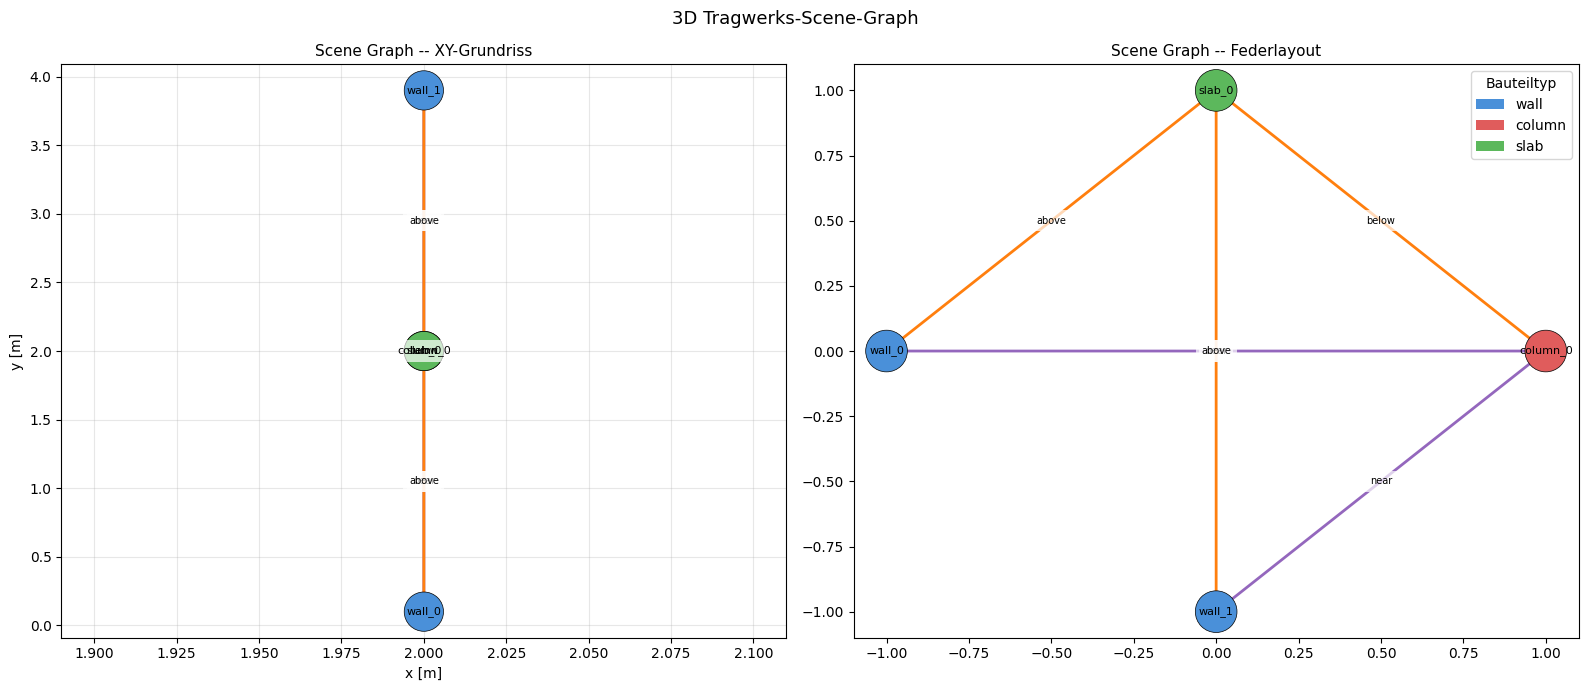

In [31]:
NODE_COLORS = {'wall': '#4a90d9', 'column': '#e05c5c', 'slab': '#5cb85c'}
EDGE_COLORS = {
    'above': '#ff7f0e', 'below': '#ff7f0e',
    'adjacent': '#2ca02c', 'near': '#9467bd',
    'inside': '#d62728', 'contains': '#d62728',
}

pos = {node: (data['centroid'][0], data['centroid'][1])
       for node, data in G.nodes(data=True)}

node_colors = [NODE_COLORS.get(G.nodes[n]['semantic_label'], '#aaaaaa') for n in G.nodes]
edge_colors = [EDGE_COLORS.get(G.edges[e]['relationship'], '#888888') for e in G.edges]
edge_labels = {e: G.edges[e]['relationship'] for e in G.edges}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

nx.draw_networkx(G, pos, ax=axes[0], node_color=node_colors, edge_color=edge_colors,
                 node_size=800, font_size=8, arrows=True, arrowsize=20, width=2)
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, ax=axes[0])
axes[0].set_title('Scene Graph -- XY-Grundriss', fontsize=11)
axes[0].set_xlabel('x [m]'); axes[0].set_ylabel('y [m]')
axes[0].grid(True, alpha=0.3)

pos_spring = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos_spring, ax=axes[1], node_color=node_colors, edge_color=edge_colors,
                 node_size=900, font_size=8, arrows=True, arrowsize=20, width=2)
nx.draw_networkx_edge_labels(G, pos_spring, edge_labels, font_size=7, ax=axes[1])
axes[1].set_title('Scene Graph -- Federlayout', fontsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in NODE_COLORS.items()]
axes[1].legend(handles=legend_elements, title='Bauteiltyp', loc='upper right')

plt.suptitle('3D Tragwerks-Scene-Graph', fontsize=13)
plt.tight_layout()
plt.show()

## Schritt 8 -- Graph-Analyse: Randbedingungen aus Topologie

Poux & Lehtola (2025), Step 9: Graphmetriken und FEM-Ableitungen:

| Graph-Eigenschaft | FEM-Randbedingung |
|-------------------|-------------------|
| `wall/column` ohne eingehende `below`-Kante | Einspannung am Fuss (z = z_min) |
| `slab` mit ausgehender `above`-Kante | Lastflaeche oben (z = z_top) |

In [32]:
def analyze_scene_graph(G: nx.DiGraph) -> Dict:
    analysis = {
        'node_count'           : G.number_of_nodes(),
        'edge_count'           : G.number_of_edges(),
        'semantic_distribution': {},
        'relationship_types'   : {},
        'weakly_connected'     : nx.number_weakly_connected_components(G),
        'avg_degree'           : sum(d for _, d in G.degree()) / G.number_of_nodes(),
        'foundation_nodes'     : [],
        'load_surface_nodes'   : [],
    }
    for node, data in G.nodes(data=True):
        lbl = data.get('semantic_label', 'unknown')
        analysis['semantic_distribution'][lbl] = \
            analysis['semantic_distribution'].get(lbl, 0) + 1
        if lbl in ('wall', 'column'):
            has_support = any(
                G.edges[e]['relationship'] == 'below'
                for e in G.in_edges(node)
            )
            if not has_support:
                analysis['foundation_nodes'].append(node)
        if lbl == 'slab':
            has_above = any(
                G.edges[e]['relationship'] == 'above'
                for e in G.out_edges(node)
            )
            if has_above:
                analysis['load_surface_nodes'].append(node)
    for _, _, data in G.edges(data=True):
        rel = data.get('relationship', 'unknown')
        analysis['relationship_types'][rel] = \
            analysis['relationship_types'].get(rel, 0) + 1
    return analysis


sg_analysis = analyze_scene_graph(G)

print('Scene-Graph-Analyse:')
print(f'  Knoten: {sg_analysis["node_count"]}   Kanten: {sg_analysis["edge_count"]}')
print(f'  Semantik:    {sg_analysis["semantic_distribution"]}')
print(f'  Beziehungen: {sg_analysis["relationship_types"]}')
print(f'  -> FEM-Einspannung : {sg_analysis["foundation_nodes"]}')
print(f'  -> FEM-Lastflaeche : {sg_analysis["load_surface_nodes"]}')

Scene-Graph-Analyse:
  Knoten: 4   Kanten: 5
  Semantik:    {'column': 1, 'slab': 1, 'wall': 2}
  Beziehungen: {'below': 1, 'near': 2, 'above': 2}
  -> FEM-Einspannung : ['column_0', 'wall_0', 'wall_1']
  -> FEM-Lastflaeche : ['slab_0']


## Schritt 9 -- Material-Mapping aus Scene Graph

Jeder Graphknoten erhaelt E-Modul und nu via BBox-Matching aus `bauteil_meta`.

In [33]:
def enrich_graph_with_material(G: nx.DiGraph, bauteil_meta: List) -> nx.DiGraph:
    for node, data in G.nodes(data=True):
        lbl  = data['semantic_label']
        bmin = onp.array(data['bounds_min'])
        bmax = onp.array(data['bounds_max'])
        E, nu = E_DEFAULT, NU_DEFAULT
        for meta in bauteil_meta:
            if meta['label'] != lbl:
                continue
            overlap = (onp.all(bmin < meta['bbox_max']) and
                       onp.all(bmax > meta['bbox_min']))
            if overlap:
                E  = meta['E']
                nu = meta['nu']
                break
        G.nodes[node]['E_kNm2'] = E
        G.nodes[node]['nu']     = nu
    return G


G = enrich_graph_with_material(G, bauteil_meta)

print(f'{"Knoten":15s}  {"Label":8s}  {"E [kN/m2]":>12s}  {"nu":>6s}')
print('-' * 46)
for node, data in G.nodes(data=True):
    print(f'  {node:13s}  {data["semantic_label"]:8s}  '
          f'{data["E_kNm2"]:12.0f}  {data["nu"]:6.2f}')

total_vol = sum(d['volume'] for _, d in G.nodes(data=True))
E_eff  = sum(d['E_kNm2'] * d['volume'] for _, d in G.nodes(data=True)) / total_vol
nu_eff = sum(d['nu']     * d['volume'] for _, d in G.nodes(data=True)) / total_vol
print(f'Volumengewichteter E_eff = {E_eff:.0f} kN/m2   nu_eff = {nu_eff:.3f}')

Knoten           Label        E [kN/m2]      nu
----------------------------------------------
  column_0       column           35000    0.20
  slab_0         slab             30000    0.20
  wall_0         wall             30000    0.20
  wall_1         wall             30000    0.20
Volumengewichteter E_eff = 30072 kN/m2   nu_eff = 0.200


## Schritt 10 -- GMSH Tet4-Netz aus Scene Graph

Die BBox jedes Graphknotens wird als `occ.addBox` in GMSH eingetragen.
`occ.fragment` erzeugt gemeinsame Knoten an Kontaktflaechen (= `adjacent`-Kanten).

In [34]:
def build_tet4_mesh_from_graph(G: nx.DiGraph, mesh_size: float, out_msh: str) -> Tuple:
    if gmsh.isInitialized():
        gmsh.finalize()
    gmsh.initialize()
    gmsh.option.setNumber('General.Terminal', 0)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMax', mesh_size)
    gmsh.option.setNumber('Mesh.CharacteristicLengthMin', mesh_size * 0.1)
    gmsh.option.setNumber('Mesh.Algorithm3D', 4)
    gmsh.model.add('scene_graph_fem')
    vol_tags = []
    for node, data in G.nodes(data=True):
        bmin = onp.array(data['bounds_min'])
        bmax = onp.array(data['bounds_max'])
        dims = bmax - bmin
        tag  = gmsh.model.occ.addBox(
            float(bmin[0]), float(bmin[1]), float(bmin[2]),
            float(dims[0]), float(dims[1]), float(dims[2]),
        )
        vol_tags.append(tag)
    gmsh.model.occ.synchronize()
    if len(vol_tags) > 1:
        all_vols = [(3, t) for t in vol_tags]
        gmsh.model.occ.fragment(all_vols, [])
        gmsh.model.occ.synchronize()
    vols = gmsh.model.getEntities(3)
    print(f'  GMSH: {len(vols)} Volumen, starte Vernetzung ...')
    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.setOrder(1)
    try:
        gmsh.model.mesh.optimize('Netgen')
    except Exception:
        pass
    gmsh.write(str(out_msh))
    n_nodes = len(gmsh.model.mesh.getNodes()[0])
    n_tets  = len(gmsh.model.mesh.getElementsByType(4)[0])
    gmsh.finalize()
    return n_nodes, n_tets


msh_path = DATA_DIR / 'msh' / 'scene_graph_fem.msh'
print('Starte GMSH-Vernetzung aus Scene Graph ...')
n_nodes, n_tets = build_tet4_mesh_from_graph(G, MESH_SIZE, msh_path)
print(f'  Netz: {n_nodes} Knoten, {n_tets} Tet4-Elemente  (DOF: {n_nodes*3})')

raw      = meshio.read(str(msh_path))
points_m = raw.points
cells_m  = raw.cells_dict.get('tetra', onp.array([]))
if len(cells_m) == 0:
    raise RuntimeError('Keine Tet4-Elemente -- GMSH-Fehler.')
mesh     = Mesh(points_m, cells_m)
ele_type = 'TET4'
print(f'BBox: x [{points_m[:,0].min():.2f}, {points_m[:,0].max():.2f}] '
      f'y [{points_m[:,1].min():.2f}, {points_m[:,1].max():.2f}] '
      f'z [{points_m[:,2].min():.2f}, {points_m[:,2].max():.2f}]')

Starte GMSH-Vernetzung aus Scene Graph ...
  GMSH: 4 Volumen, starte Vernetzung ...
  Netz: 2178 Knoten, 6665 Tet4-Elemente  (DOF: 6534)

BBox: x [0.00, 4.00] y [0.00, 4.00] z [0.00, 3.00]


## Schritt 11 -- Randbedingungen aus Scene Graph

Einspannung und Lastflaeche werden aus der Graph-Topologie (Schritt 8) abgeleitet.

In [35]:
z_min  = float(points_m[:, 2].min())
z_top  = float(points_m[:, 2].max())
x_min  = float(points_m[:, 0].min())
x_max  = float(points_m[:, 0].max())
tol_bc = MESH_SIZE / 4.0

EG_kN  = sum(GAMMA_BETON * d['volume'] for _, d in G.nodes(data=True))
A_deck = (x_max - x_min) * (points_m[:, 1].max() - points_m[:, 1].min())
q_tot  = EG_kN / A_deck + Q_NUTZLAST
print(f'Eigengewicht: {EG_kN:.1f} kN  |  Grundriss: {A_deck:.1f} m2')
print(f'Gesamtlast:   {q_tot:.2f} kN/m2  (EG + {Q_NUTZLAST} kN/m2 Nutzlast)')
print(f'z_min={z_min:.3f} m   z_top={z_top:.3f} m   tol_bc={tol_bc:.4f} m')

def zero(p): return 0.0
def at_base(p): return jnp.isclose(p[2], z_min, atol=tol_bc)
def at_x0(p):   return jnp.isclose(p[0], x_min, atol=tol_bc)
def at_xL(p):   return jnp.isclose(p[0], x_max, atol=tol_bc)
def at_top(p):  return jnp.isclose(p[2], z_top, atol=tol_bc)

dirichlet_bc_info = [
    [at_base, at_base, at_base, at_x0, at_xL],
    [0,       1,       2,       0,     0    ],
    [zero,    zero,    zero,    zero,  zero ],
]
location_fns = [at_top]

n_base = int(onp.sum(onp.abs(points_m[:, 2] - z_min) < tol_bc))
n_top  = int(onp.sum(onp.abs(points_m[:, 2] - z_top) < tol_bc))
print(f'Einspannung z=0: {n_base} Knoten  |  Lastflaeche z=top: {n_top} Knoten')

Eigengewicht: 194.8 kN  |  Grundriss: 16.0 m2
Gesamtlast:   17.18 kN/m2  (EG + 5.0 kN/m2 Nutzlast)
z_min=0.000 m   z_top=3.000 m   tol_bc=0.0625 m
Einspannung z=0: 108 Knoten  |  Lastflaeche z=top: 340 Knoten


## Schritt 12 -- JaxFEM-Solver (lineare 3D-Elastizitaet)

In [36]:
mu    = E_eff / (2.0 * (1.0 + nu_eff))
lmbda = E_eff * nu_eff / ((1.0 + nu_eff) * (1.0 - 2.0 * nu_eff))
q     = q_tot

print(f'E_eff={E_eff:.0f} kN/m2   nu_eff={nu_eff:.3f}')
print(f'mu={mu:.1f}   lambda={lmbda:.1f}   q={q:.2f} kN/m2')


class SceneGraphFEM(Problem):
    def get_tensor_map(self):
        def stress(u_grad):
            eps = 0.5 * (u_grad + u_grad.T)
            return lmbda * jnp.trace(eps) * jnp.eye(self.dim) + 2.0 * mu * eps
        return stress

    def get_surface_maps(self):
        def load_top(u, x):
            return jnp.array([0.0, 0.0, q])
        return [load_top]


problem = SceneGraphFEM(
    mesh=mesh, vec=3, dim=3, ele_type=ele_type,
    dirichlet_bc_info=dirichlet_bc_info,
    location_fns=location_fns,
)

print(f'Problem: {len(cells_m)} Tet4-Elemente, {len(points_m)*3} DOF')
print('Loese lineares Gleichungssystem (UMFPACK) ...')
sol = solver(problem, solver_options={'umfpack_solver': {}})

ux    = onp.array(sol[0][:, 0])
uy    = onp.array(sol[0][:, 1])
uz    = onp.array(sol[0][:, 2])
u_abs = onp.sqrt(ux**2 + uy**2 + uz**2)

print(f'u_z_max (Absenkung): {uz.min()*1000:.3f} mm')
print(f'|u|_max:             {u_abs.max()*1000:.3f} mm')
assert uz.min() < 0, 'Keine Absenkung -- Last-Vorzeichen pruefen!'

[04-25 18:23:04][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[04-25 18:23:04][DEBUG] jax_fem: ele_type = TET4, quad_points.shape = (num_quads, dim) = (1, 3)
[04-25 18:23:04][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 1, 3)
[04-25 18:23:04][DEBUG] jax_fem: Done pre-computations, took 0.022075891494750977 [s]
[04-25 18:23:04][INFO] jax_fem: Solving a problem with 6665 cells, 2178x3 = 6534 dofs.
[04-25 18:23:04][INFO] jax_fem: Element type is TET4, using 1 quad points per element.
[04-25 18:23:04][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[04-25 18:23:04][DEBUG] jax_fem: Start timing
[04-25 18:23:04][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-25 18:23:04][DEBUG] jax_fem: Function split_and_compute_cell took 0.0613 seconds
[04-25 18:23:04][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-25 18:23:04][DEBUG] jax_fem: Before, l_2 res = 15.456381076854063, relative l_2 

E_eff=30072 kN/m2   nu_eff=0.200
mu=12529.9   lambda=8353.3   q=17.18 kN/m2
Problem: 6665 Tet4-Elemente, 6534 DOF
Loese lineares Gleichungssystem (UMFPACK) ...


[04-25 18:23:04][DEBUG] jax_fem: Scipy Solver - Finished solving, linear solve res = 1.6421009002027036e-11
[04-25 18:23:04][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[04-25 18:23:04][DEBUG] jax_fem: Function split_and_compute_cell took 0.0021 seconds
[04-25 18:23:04][DEBUG] jax_fem: Creating sparse matrix with scipy...
[04-25 18:23:04][DEBUG] jax_fem: l_2 res = 1.6235777091187262e-11, relative l_2 res = 1.0504255174906592e-12
[04-25 18:23:04][INFO] jax_fem: Solve took 0.19063901901245117 [s]
[04-25 18:23:04][INFO] jax_fem: max of dofs = 0.04421264408388845
[04-25 18:23:04][INFO] jax_fem: min of dofs = -0.22137547263984236


u_z_max (Absenkung): -221.375 mm
|u|_max:             221.376 mm


## Schritt 13 -- Spannungsberechnung (Tet4)

In [37]:
def compute_stress_tet4(
    pts: onp.ndarray, cells: onp.ndarray,
    u_sol: onp.ndarray, lmbda: float, mu: float,
) -> onp.ndarray:
    sigma_gp, gp_coords = [], []
    for cell in cells:
        p  = pts[cell]
        ue = u_sol[cell]
        J  = p[1:4] - p[0]
        try:
            J_inv = onp.linalg.inv(J.T)
        except onp.linalg.LinAlgError:
            continue
        dN   = onp.array([[-1,-1,-1],[1,0,0],[0,1,0],[0,0,1]], dtype=float)
        dNdx = dN @ J_inv
        grad_u = ue.T @ dNdx
        eps    = 0.5 * (grad_u + grad_u.T)
        sig    = lmbda * onp.trace(eps) * onp.eye(3) + 2.0 * mu * eps
        sigma_gp.append([sig[0,0],sig[1,1],sig[2,2],sig[0,1],sig[0,2],sig[1,2]])
        gp_coords.append(p.mean(axis=0))
    sigma_gp  = onp.array(sigma_gp)
    gp_coords = onp.array(gp_coords)
    _, idx = cKDTree(gp_coords).query(pts)
    return sigma_gp[idx]


sigma = compute_stress_tet4(points_m, cells_m, onp.array(sol[0]),
                             float(lmbda), float(mu))
s11, s22, s33 = sigma[:,0], sigma[:,1], sigma[:,2]
s12, s13, s23 = sigma[:,3], sigma[:,4], sigma[:,5]
s_vm = onp.sqrt(0.5 * ((s11-s22)**2 + (s22-s33)**2 + (s33-s11)**2
                       + 6*(s12**2 + s13**2 + s23**2)))

print(f'sigma_33: {s33.min():.1f} ... {s33.max():.1f} kN/m2')
print(f'sigma_vM_max: {s_vm.max():.1f} kN/m2  ({s_vm.max()/1000:.3f} MN/m2)')

sigma_33: -2364.2 ... 679.6 kN/m2
sigma_vM_max: 2255.7 kN/m2  (2.256 MN/m2)


## Schritt 14 -- PyVista-Visualisierung

Warpfaktor: x1


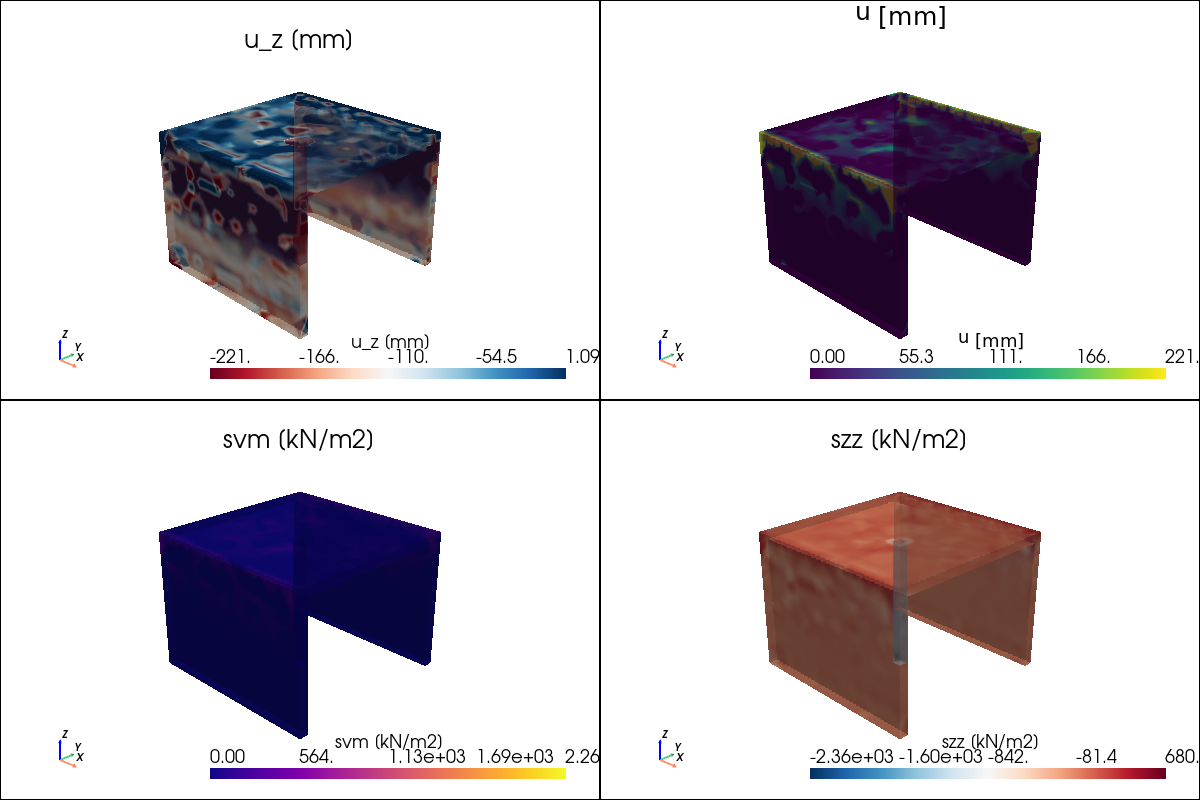

In [38]:
pv.set_jupyter_backend('static')

cell_array = onp.hstack([
    onp.full((len(cells_m), 1), 4, dtype=onp.int64),
    cells_m.astype(onp.int64)
]).flatten()
cell_types = onp.full(len(cells_m), pv.CellType.TETRA)

grid = pv.UnstructuredGrid(cell_array, cell_types, points_m)
grid.point_data['uz_mm']    = uz * 1000
grid.point_data['u_abs_mm'] = u_abs * 1000
grid.point_data['sigma_vm'] = s_vm
grid.point_data['sigma_zz'] = s33

max_uz   = max(abs(uz.min()), abs(uz.max()))
char_len = float(points_m[:,2].max() - points_m[:,2].min())
warp_fac = max(round(min(0.05 * char_len / max(max_uz, 1e-12), 500.0)), 1)
print(f'Warpfaktor: x{warp_fac}')

disp_vec = onp.column_stack([ux, uy, uz])
grid.point_data['displacement'] = disp_vec
warped = grid.warp_by_vector('displacement', factor=warp_fac)
warped.point_data['sigma_vm'] = s_vm
warped.point_data['uz_mm']    = uz * 1000

cam_pos = [(12, -8, 8), (2, 2, 1.5), (0, 0, 1)]

plotter = pv.Plotter(shape=(2, 2), window_size=(1200, 800), off_screen=True)
plotter.set_background('white')
for row, col, field, title, cmap in [
    (0, 0, 'uz_mm',    'u_z [mm]',     'RdBu'),
    (0, 1, 'u_abs_mm', '|u| [mm]',     'viridis'),
    (1, 0, 'sigma_vm', 'svm [kN/m2]',  'plasma'),
    (1, 1, 'sigma_zz', 'szz [kN/m2]',  'RdBu_r'),
]:
    plotter.subplot(row, col)
    plotter.add_mesh(grid, scalars=field, cmap=cmap, show_edges=False,
                     opacity=0.92, scalar_bar_args={'title': title})
    plotter.add_title(title, font_size=10)
    plotter.camera_position = cam_pos
    plotter.add_axes()
plotter.show(title=f'Scene Graph -> JaxFEM  |  {len(cells_m)} Tet4')

## Schritt 15 -- Verformte Geometrie (Warp)

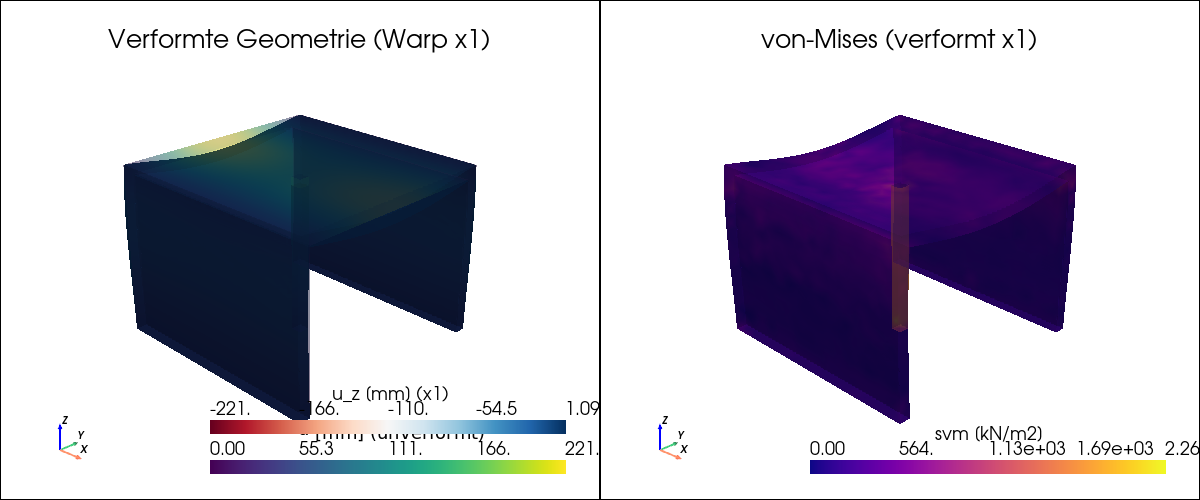

VTK gespeichert: ../data/vtk/scene_graph_fem.vtu


In [39]:
plotter2 = pv.Plotter(shape=(1, 2), window_size=(1200, 500), off_screen=True)
plotter2.set_background('white')

plotter2.subplot(0, 0)
plotter2.add_mesh(grid,   scalars='u_abs_mm', cmap='viridis',
                  opacity=0.3, show_edges=False,
                  scalar_bar_args={'title': '|u| [mm] (unverformt)'})
plotter2.add_mesh(warped, scalars='uz_mm', cmap='RdBu',
                  opacity=0.9, show_edges=False,
                  scalar_bar_args={'title': f'u_z [mm] (x{warp_fac})'})
plotter2.add_title(f'Verformte Geometrie (Warp x{warp_fac})', font_size=10)
plotter2.camera_position = cam_pos
plotter2.add_axes()

plotter2.subplot(0, 1)
plotter2.add_mesh(warped, scalars='sigma_vm', cmap='plasma',
                  opacity=0.95, show_edges=False,
                  scalar_bar_args={'title': 'svm [kN/m2]'})
plotter2.add_title(f'von-Mises (verformt x{warp_fac})', font_size=10)
plotter2.camera_position = cam_pos
plotter2.add_axes()

plotter2.show()

vtu_path = str(DATA_DIR / 'vtk' / 'scene_graph_fem.vtu')
save_sol(problem.fes[0], sol[0], vtu_path)
print('VTK gespeichert:', vtu_path)

## Schritt 16 -- FEM-Ergebnisse in Scene Graph rueckschreiben

Poux & Lehtola (2025), Step 12: Der angereicherte Graph wird als
JSON exportiert -- ein abfragbarer Wissensgraph fuer Spatial AI.

In [40]:
def write_fem_results_to_graph(
    G: nx.DiGraph, points_m, uz, u_abs, s_vm
) -> nx.DiGraph:
    for node, data in G.nodes(data=True):
        bmin = onp.array(data['bounds_min'])
        bmax = onp.array(data['bounds_max'])
        tol  = 1e-6
        mask = (
            (points_m[:,0] >= bmin[0]-tol) & (points_m[:,0] <= bmax[0]+tol) &
            (points_m[:,1] >= bmin[1]-tol) & (points_m[:,1] <= bmax[1]+tol) &
            (points_m[:,2] >= bmin[2]-tol) & (points_m[:,2] <= bmax[2]+tol)
        )
        if mask.sum() == 0:
            continue
        G.nodes[node]['uz_min_mm']    = round(float(uz[mask].min() * 1000), 3)
        G.nodes[node]['u_abs_max_mm'] = round(float(u_abs[mask].max() * 1000), 3)
        G.nodes[node]['sigma_vm_max'] = round(float(s_vm[mask].max()), 1)
    return G


G = write_fem_results_to_graph(G, points_m, uz, u_abs, s_vm)

hdr = f'{"Knoten":15s}  {"Label":8s}  {"uz_min[mm]":>12s}  {"uabs[mm]":>10s}  {"svm_max":>10s}'
print(hdr)
print('-' * 62)
for node, data in G.nodes(data=True):
    print(f'  {node:13s}  {data["semantic_label"]:8s}  '
          f'{data.get("uz_min_mm", 0.0):>12.3f}  '
          f'{data.get("u_abs_max_mm", 0.0):>10.3f}  '
          f'{data.get("sigma_vm_max", 0.0):>10.1f}')

sg_json = {
    'meta': {
        'description': 'Scene Graph FEM -- Tragwerk 3D',
        'mesh_size'  : MESH_SIZE,
        'n_elements' : int(len(cells_m)),
        'n_nodes_fem': int(len(points_m)),
        'E_eff_kNm2' : round(float(E_eff), 1),
        'nu_eff'     : round(float(nu_eff), 4),
        'q_kNm2'     : round(float(q), 2),
        'units'      : 'kN + m',
    },
    'nodes': {
        node: {k: v for k, v in data.items() if not isinstance(v, onp.ndarray)}
        for node, data in G.nodes(data=True)
    },
    'edges': [
        {'from': u, 'to': v, 'relationship': data['relationship']}
        for u, v, data in G.edges(data=True)
    ],
}

json_path = DATA_DIR / 'scene_graph_fem.json'
with open(json_path, 'w', encoding='utf-8') as fh:
    json.dump(sg_json, fh, indent=2, ensure_ascii=False, default=str)
print(f'Scene Graph (JSON) gespeichert: {json_path}')

Knoten           Label       uz_min[mm]    uabs[mm]     svm_max
--------------------------------------------------------------
  column_0       column        -150.130     150.140      2255.7
  slab_0         slab          -221.375     221.376      1566.6
  wall_0         wall           -24.046      45.179       823.8
  wall_1         wall           -23.474      44.998       872.3
Scene Graph (JSON) gespeichert: ../data/scene_graph_fem.json


## Schritt 17 -- LLM-Prompt aus Scene Graph

Poux & Lehtola (2025), Step 12: Der angereicherte Graph wird in einen
strukturierten Textprompt umgewandelt fuer Spatial-AI-Abfragen.

Beispielabfragen:
- *Welches Bauteil hat die groesste Absenkung?*
- *Ist die Stuetze strukturell kritischer als die Waende?*
- *Wo liegt die maximale von-Mises-Spannung?*

In [41]:
def scene_graph_to_llm_prompt(G: nx.DiGraph, uz, u_abs, s_vm, q) -> str:
    lines = [
        '=== TRAGWERK SCENE GRAPH -- FEM-Ergebnisse ===',
        '',
        'BAUTEILE (Knoten):',
    ]
    for node, data in G.nodes(data=True):
        c = data.get('centroid', [0, 0, 0])
        lines.append(
            f'  [{node}]  Typ={data["semantic_label"]}  '
            f'Schwerpunkt=({c[0]:.1f}, {c[1]:.1f}, {c[2]:.1f}) m  '
            f'E={data.get("E_kNm2", 0):.0f} kN/m2  '
            f'uz_min={data.get("uz_min_mm", 0):.3f} mm  '
            f'svm_max={data.get("sigma_vm_max", 0):.1f} kN/m2'
        )
    lines += ['', 'RAEUMLICHE BEZIEHUNGEN (Kanten):']
    for u_node, v_node, edata in G.edges(data=True):
        lines.append(f'  {u_node}  --[{edata["relationship"]}]-->  {v_node}')
    lines += [
        '',
        'GLOBALE ERGEBNISSE:',
        f'  Maximale Absenkung  : {uz.min()*1000:.3f} mm',
        f'  Maximale Verformung : {u_abs.max()*1000:.3f} mm',
        f'  Maximale svm        : {s_vm.max():.1f} kN/m2',
        f'  Gesamtlast          : {q:.2f} kN/m2',
        '',
        '=============================================',
    ]
    return '\n'.join(lines)


prompt = scene_graph_to_llm_prompt(G, uz, u_abs, s_vm, q)
print(prompt)

user_question = 'Welches Bauteil ist strukturell am staerksten beansprucht und warum?'
full_prompt = (
    prompt
    + '\n\nFRAGE: ' + user_question
    + '\n\nAntworte basierend auf den FEM-Ergebnissen im Scene Graph.'
    + ' Beruecksichtige: (1) von-Mises-Vergleichsspannung,'
    + ' (2) Verformungen, (3) strukturelle Position im Tragwerk (Kanten im Graph).'
)
print(f'\nLLM-Prompt bereit ({len(full_prompt)} Zeichen)')
print('  -> client.messages.create(model="claude-sonnet-4-6", '
      'messages=[{"role":"user","content":full_prompt}])')

=== TRAGWERK SCENE GRAPH -- FEM-Ergebnisse ===

BAUTEILE (Knoten):
  [column_0]  Typ=column  Schwerpunkt=(2.0, 2.0, 1.4) m  E=35000 kN/m2  uz_min=-150.130 mm  svm_max=2255.7 kN/m2
  [slab_0]  Typ=slab  Schwerpunkt=(2.0, 2.0, 2.9) m  E=30000 kN/m2  uz_min=-221.375 mm  svm_max=1566.6 kN/m2
  [wall_0]  Typ=wall  Schwerpunkt=(2.0, 0.1, 1.4) m  E=30000 kN/m2  uz_min=-24.046 mm  svm_max=823.8 kN/m2
  [wall_1]  Typ=wall  Schwerpunkt=(2.0, 3.9, 1.4) m  E=30000 kN/m2  uz_min=-23.474 mm  svm_max=872.3 kN/m2

RAEUMLICHE BEZIEHUNGEN (Kanten):
  column_0  --[below]-->  slab_0
  column_0  --[near]-->  wall_0
  column_0  --[near]-->  wall_1
  slab_0  --[above]-->  wall_0
  slab_0  --[above]-->  wall_1

GLOBALE ERGEBNISSE:
  Maximale Absenkung  : -221.375 mm
  Maximale Verformung : 221.376 mm
  Maximale svm        : 2255.7 kN/m2
  Gesamtlast          : 17.18 kN/m2


LLM-Prompt bereit (1170 Zeichen)
  -> client.messages.create(model="claude-sonnet-4-6", messages=[{"role":"user","content":full_prompt}])

## Zusammenfassung

| Schritt | Methode | Ergebnis |
|---------|---------|----------|
| 1 | Synthetische Punktwolke | 7 300 Punkte, 3 Label |
| 2 | Matplotlib-Schnittbilder | XZ + YZ |
| 3 | DBSCAN-Clustering | Objekt-Instanzen |
| 4 | Feature-Extraktion | Volumen, Hoehe, Kompaktheit |
| 5 | Raeumliche Beziehungsanalyse | above, adjacent, near |
| 6 | NetworkX DiGraph | Scene Graph |
| 7 | Graph-Visualisierung | XY-Grundriss + Federlayout |
| 8 | Graph-Analyse | Randbedingungen automatisch |
| 9 | Material-Mapping | E-Modul + nu pro Knoten |
| 10 | GMSH Tet4-Netz | Aus BBox der Graphknoten |
| 11 | JaxFEM Randbedingungen | Aus Graphtopologie |
| 12 | JaxFEM-Solver | Lineare 3D-Elastizitaet |
| 13 | Spannungen | von-Mises + Voigt-Tensor |
| 14-15 | PyVista | 3D-Visualisierung + Warp |
| 16 | Ergebnis-Rueckschreiben | FEM-Werte in Graphknoten |
| 17 | LLM-Prompt | Abfragbarer Wissensgraph |

**Erweiterungen:**
- Echte LiDAR-Punktwolke (.las / .ply) als Eingabe
- OpenUSD-Export des angereicherten Scene Graphs
- Heterogene Materialfelder (bauteilweise JaxFEM-Subprobleme)
- LLM-Integration via Anthropic API (`claude-sonnet-4-6`)

In [42]:
print('=' * 58)
print('  Scene Graph -> JaxFEM -- Zusammenfassung')
print('=' * 58)
print(f'  Graphknoten    : {G.number_of_nodes()} Bauteile')
print(f'  Graphkanten    : {G.number_of_edges()} Beziehungen')
print(f'  Tet4-Elemente  : {len(cells_m)}')
print(f'  Knoten / DOF   : {len(points_m)} / {len(points_m)*3}')
print(f'  E_eff / nu_eff : {E_eff:.0f} kN/m2  /  {nu_eff:.2f}')
print(f'  Gesamtlast     : {q:.2f} kN/m2')
print('-' * 58)
print(f'  u_z_max        : {uz.min()*1000:.3f} mm')
print(f'  |u|_max        : {u_abs.max()*1000:.3f} mm')
print(f'  sigma_vM_max   : {s_vm.max():.1f} kN/m2')
print(f'  sigma_zz_min   : {s33.min():.1f} kN/m2 (Druckspannung)')
print('=' * 58)

  Scene Graph -> JaxFEM -- Zusammenfassung
  Graphknoten    : 4 Bauteile
  Graphkanten    : 5 Beziehungen
  Tet4-Elemente  : 6665
  Knoten / DOF   : 2178 / 6534
  E_eff / nu_eff : 30072 kN/m2  /  0.20
  Gesamtlast     : 17.18 kN/m2
----------------------------------------------------------
  u_z_max        : -221.375 mm
  |u|_max        : 221.376 mm
  sigma_vM_max   : 2255.7 kN/m2
  sigma_zz_min   : -2364.2 kN/m2 (Druckspannung)
